In [26]:
class LinearSchedule():
    def __init__(self, start_val, end_val, start_step, end_step):
        self.sv = start_val
        self.ev = end_val
        self.ss = start_step
        self.es = end_step

    def sample(self, t):
        if t <= self.ss:
            return self.sv
        if t >= self.es:
            return self.ev
        frac = (t - self.ss) / (self.es - self.ss)
        return self.ev * frac + self.sv * (1 - frac)
    
test = LinearSchedule(0,1,5,10)

In [ ]:
import torch
logits =  torch.tensor([2.2755, 0.0000, 0.0000, 2.4833, 0.0000, 0.0000, 3.6467, 1.1626, 5.1386,
        3.0232, 0.0000, 4.7909, 2.3992, 0.7138, 3.2939, 0.0000, 3.8536, 1.3899,
        2.3867, 0.0000, 1.9341, 3.7350, 2.4375, 2.7620, 3.3895, 3.2603, 2.0326,
        3.5593, 0.9288, 0.3489, 2.7837, 0.0000, 3.8545, 0.0000, 3.4533, 2.5841,
        1.8567, 2.8093, 1.4299, 1.4155, 2.4154, 0.0000, 3.5756, 3.3848, 2.4745,
        2.1030, 1.3719, 3.0898, 0.3020, 2.6788, 3.1324, 0.0000, 1.2589, 0.0000,
        2.1895, 5.5009, 0.0000, 2.8079, 1.6864, 3.0948, 0.0000, 3.6582, 4.2929,
        0.0000, 2.1435, 2.2847, 1.7379, 0.0000, 1.4771, 0.0000, 4.4352, 0.0000,
        0.0000, 1.8048, 0.2968, 0.0000, 2.2518, 1.1693, 1.0449, 1.8251, 2.2656,
        3.7674, 1.6757, 2.6260, 0.0000, 2.8410, 0.0000, 0.0000, 2.3094, 4.3674,
        1.9972, 1.6160, 2.7691, 0.0000, 2.5009, 2.6154, 0.0000, 0.0000, 1.3780,
        0.0000, 0.0000, 0.0000, 2.9793, 4.3797, 0.0000, 3.2605, 0.7489, 3.0616,
        1.4214, 2.1818])
high = 1.23828125
low = 0.984375
beta = (high+low)/2
logits = logits*beta
# logits = logits*0.175

disc_dist = torch.distributions.Categorical(logits=logits)
print((high+low)/2)
if torch.abs(disc_dist.entropy()-3.561305124200372)<=0.01:
    print('done')
disc_dist.entropy()

1.111328125


tensor(3.6159)

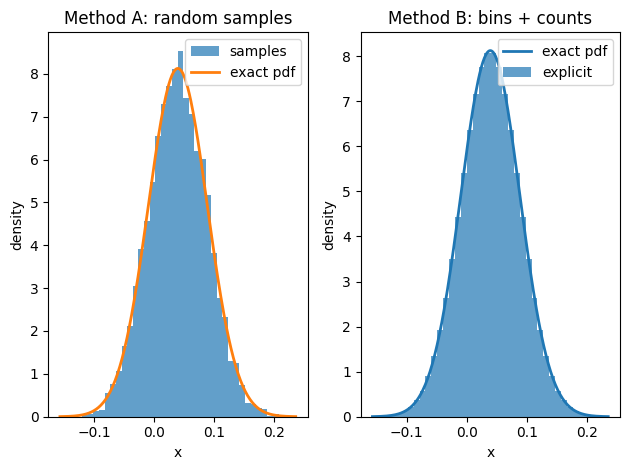

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm            # just for the pdf

# ── input list: [mean, std] ──────────────────────────────────────────────
gauss_stats = [0.0394, 0.0491]                # μ = 0.5,  σ = 1.0
mu, std = gauss_stats

# ── A) sample-based histogram ────────────────────────────────────────────
samples = np.random.normal(loc=mu, scale=std, size=10_000)

plt.subplot(1, 2, 1)
plt.hist(samples, bins=40, density=True, alpha=0.7, label="samples")
xs = np.linspace(mu - 4*std, mu + 4*std, 300)
plt.plot(xs, norm.pdf(xs, mu, std), lw=2, label="exact pdf")
plt.title("Method A: random samples")
plt.xlabel("x"), plt.ylabel("density"), plt.legend()

# ── B) explicit-bins histogram ───────────────────────────────────────────
# fixed bin edges
bin_edges = np.linspace(mu - 4*std, mu + 4*std, 41)
# compute probability mass in each bin analytically
cdf = norm.cdf(bin_edges, mu, std)
bin_mass = np.diff(cdf)                 # length 40
# Convert probability mass to counts so bar height = density
counts = bin_mass / np.diff(bin_edges)  # density in each bin

plt.subplot(1, 2, 2)
centres = 0.5 * (bin_edges[1:] + bin_edges[:-1])
plt.bar(centres, counts, width=np.diff(bin_edges), alpha=0.7, label="explicit")
plt.plot(xs, norm.pdf(xs, mu, std), lw=2, label="exact pdf")
plt.title("Method B: bins + counts")
plt.xlabel("x"), plt.ylabel("density"), plt.legend()

plt.tight_layout()
plt.show()


In [35]:
b = [2, 1, 3]              # rewards
a = ['a', 'b', 'c']        # designs
from itertools import islice
# Step 1: Zip with original index
paired = list(enumerate(zip(a, b)))  # [(0, ('a', 2)), (1, ('b', 1)), (2, ('c', 3))]

# Step 2: Sort by reward (b)
paired_sorted = sorted(paired, key=lambda x: x[1][1], reverse=True)
top3 = list(islice(paired_sorted, 3))  
# Step 3: Print sorted order + original index
for i, (orig_idx, (design, reward)) in enumerate(top3):
    print(f"Rank {i}: original idx = {orig_idx}, design = {design}, reward = {reward}")


Rank 0: original idx = 2, design = c, reward = 3
Rank 1: original idx = 0, design = a, reward = 2
Rank 2: original idx = 1, design = b, reward = 1


In [ ]:
import matplotlib.pyplot as plt
import wandb
wandb.init(project="test_matplot")
val = [2,4,6,2,1,9]
average_discrete_design = {}
for i in range(5):
    average_discrete_design[i] = {}
    for j in range(len(val)):
       average_discrete_design[i][j] = val[j]

# keys = list(average_discrete_design[4].keys())
# vals = list(average_discrete_design[4].values())
# plt.plot(vals)
# wandb.log({"plot": plt})
# wandb.finish()
xs = list(range(len(val)))
ys   = []            # list[list[int]]
keys = [] 
for body_len,counts in average_discrete_design.items():
    print(counts.values())
    y = list(counts)
    print(y)
    # ys.append(y)
    keys.append(str(body_len))          # legend label
    # print(keys)
bar = wandb.plot.bar(
            xs       = xs,
            ys       = ys,                  # list of series
            keys     = keys,                # one key per body_length
            title    = "Idx count per body-length",
            xname    = "design idx")
wandb.log({f"test/idx_count_plot": bar})

dict_values([2, 4, 6, 2, 1, 9])
[0, 1, 2, 3, 4, 5]
dict_values([2, 4, 6, 2, 1, 9])
[0, 1, 2, 3, 4, 5]
dict_values([2, 4, 6, 2, 1, 9])
[0, 1, 2, 3, 4, 5]
dict_values([2, 4, 6, 2, 1, 9])
[0, 1, 2, 3, 4, 5]
dict_values([2, 4, 6, 2, 1, 9])
[0, 1, 2, 3, 4, 5]
